In [1]:
import torch
import torchvision
from packaging import version # Standard library for clean version checks

# Define your requirements
required_torch = "2.0.0"
required_vision = "0.15.0"

def check_and_install():
    t_ver = torch.__version__.split('+')[0] # Remove metadata like '+cu118'
    v_ver = torchvision.__version__.split('+')[0]

    if (version.parse(t_ver) >= version.parse(required_torch) and 
        version.parse(v_ver) >= version.parse(required_vision)):
        print(f"[READY] Torch: {t_ver}, Torchvision: {v_ver}")
    else:
        print(f"[UPDATE] Versions too low. Installing updates...")
        # Note the capital -U
        !pip3 install -U torch torchvision torchtext torchaudio --index-url https://download.pytorch.org/whl/cu118
        print("[INFO] Please restart your kernel/runtime to apply updates.")

check_and_install()

[READY] Torch: 2.9.1, Torchvision: 0.24.1


In [2]:
# Continue with regular imports
import matplotlib.pyplot as plt
import torch
import torchvision

from torch import nn
from torchvision import transforms

# Try to get torchinfo, install it if it doesn't work
try:
    from torchinfo import summary
except:
    print("[INFO] Couldn't find torchinfo... installing it.")
    !pip install -q torchinfo
    from torchinfo import summary

# Try to import the going_modular directory, download it from GitHub if it doesn't work
try:
    from going_modular.going_modular import data_setup, engine
    from helper_functions import download_data, set_seeds, plot_loss_curves
except:
    # Get the going_modular scripts
    print("[INFO] Couldn't find going_modular or helper_functions scripts... downloading them from GitHub.")
    !git clone https://github.com/mrdbourke/pytorch-deep-learning
    !mv pytorch-deep-learning/going_modular .
    !mv pytorch-deep-learning/helper_functions.py . # get the helper_functions.py script
    !rm -rf pytorch-deep-learning
    from going_modular.going_modular import data_setup, engine
    from helper_functions import download_data, set_seeds, plot_loss_curves

In [3]:
device = "cuda" if torch.cuda.is_available() else "mps"
device

'mps'

In [4]:
# Download pizza, steak, sushi images from GitHub
data_20_percent_path = download_data(source="https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi_20_percent.zip",
                                     destination="pizza_steak_sushi_20_percent")

data_20_percent_path

[INFO] data/pizza_steak_sushi_20_percent directory exists, skipping download.


PosixPath('data/pizza_steak_sushi_20_percent')

In [5]:

train_dir=data_20_percent_path/"train"
test_dir=data_20_percent_path/"test"
train_dir, test_dir


(PosixPath('data/pizza_steak_sushi_20_percent/train'),
 PosixPath('data/pizza_steak_sushi_20_percent/test'))

In [6]:
effnetb2_weights = torchvision.models.EfficientNet_B2_Weights.DEFAULT
effnetb2_transforms = effnetb2_weights.transforms()
effnetb2=torchvision.models.efficientnet_b2(weights=effnetb2_weights)
for param in effnetb2.parameters():
    param.requires_grad = False


In [7]:
set_seeds()
effnetb2.classifier = nn.Sequential(
    nn.Dropout(p=0.3, inplace=True),
    nn.Linear(in_features=1408, out_features=3)
).to(device)
summary(effnetb2, input_size=(1, 3, 260, 260),col_names=["input_size", "output_size", "num_params", "trainable"],col_width=20,row_settings=["var_names"])  

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [1, 3, 260, 260]     [1, 3]               --                   Partial
├─Sequential (features)                                      [1, 3, 260, 260]     [1, 1408, 9, 9]      --                   False
│    └─Conv2dNormActivation (0)                              [1, 3, 260, 260]     [1, 32, 130, 130]    --                   False
│    │    └─Conv2d (0)                                       [1, 3, 260, 260]     [1, 32, 130, 130]    (864)                False
│    │    └─BatchNorm2d (1)                                  [1, 32, 130, 130]    [1, 32, 130, 130]    (64)                 False
│    │    └─SiLU (2)                                         [1, 32, 130, 130]    [1, 32, 130, 130]    --                   --
│    └─Sequential (1)                                        [1, 32, 130, 130]    [1, 1

In [8]:
import torch
import torchvision
def create_effnet2_model(num_classes:int=3,seed:int=42):
    weights=torchvision.models.EfficientNet_B2_Weights.DEFAULT
    transforms=weights.transforms()
    model=torchvision.models.efficientnet_b2(weights=weights)
    for params in model.parameters():
        params.requires_grad = False
    torch.manual_seed(seed)
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3, inplace=True),
        nn.Linear(in_features=1408, out_features=num_classes)
    ).to(device)
    return model, transforms
    

In [9]:
effnetb2,effnetb2_transforms=create_effnet2_model(num_classes=3, seed=42)

In [10]:
# Create DataLoaders and setup data
from going_modular.going_modular import data_setup
train_dataloader, test_dataloader, class_names = data_setup.create_dataloaders(
    train_dir=train_dir,
    test_dir=test_dir,
    transform=effnetb2_transforms,
    batch_size=32
)

In [11]:
len(train_dataloader), len(test_dataloader)

(15, 5)

In [13]:
from going_modular.going_modular import engine
loss_fn=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(effnetb2.parameters(),lr=1e-3)
set_seeds()
effnetb2_results=engine.train(model=effnetb2,
                              train_dataloader=train_dataloader,
                              test_dataloader=test_dataloader,
                              optimizer=optimizer,
                              loss_fn=loss_fn,
                              epochs=5,
                              device=device) # type: ignore


  0%|          | 0/5 [00:00<?, ?it/s]

/Users/abdrhmn/.pyenv/versions/pytorch/lib/python3.10/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch: 1 | train_loss: 0.9817 | train_acc: 0.5729 | test_loss: 0.7343 | test_acc: 0.9625
Epoch: 2 | train_loss: 0.7070 | train_acc: 0.8667 | test_loss: 0.5739 | test_acc: 0.9500
Epoch: 3 | train_loss: 0.6039 | train_acc: 0.8167 | test_loss: 0.4819 | test_acc: 0.9625
Epoch: 4 | train_loss: 0.4490 | train_acc: 0.9021 | test_loss: 0.4318 | test_acc: 0.9375
Epoch: 5 | train_loss: 0.4297 | train_acc: 0.9146 | test_loss: 0.3900 | test_acc: 0.9472


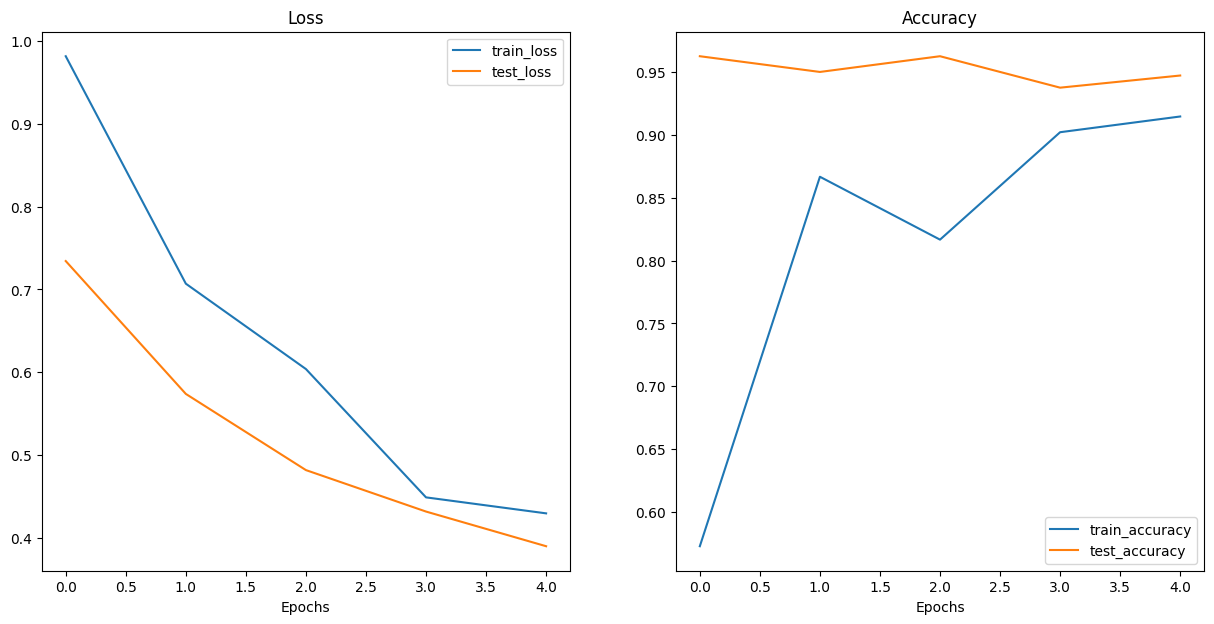

In [14]:
from helper_functions import plot_loss_curves
plot_loss_curves(effnetb2_results)

In [15]:
# Save the model
from going_modular.going_modular import utils

utils.save_model(model=effnetb2,
                 target_dir="models",
                 model_name="09_pretrained_vit_feature_extractor_pizza_steak_sushi_20_percent.pth")

[INFO] Saving model to: models/09_pretrained_vit_feature_extractor_pizza_steak_sushi_20_percent.pth
